# 电商客户 90 天不活跃风险预测

## 业务问题

如果企业每月只能触达一部分客户，应该优先联系哪些客户？本项目在每个月初生成客户快照，使用此前 180 天的交易行为，预测客户在未来 90 天内是否**没有再次成功购买**。

这里使用“90 天购买不活跃风险”，而不是声称预测永久流失。因为公开交易数据没有账户注销、订阅终止或客户主动流失字段，90 天无购买是一个可复现、可运营的代理标签。

## 项目亮点

- 使用 106 万余行真实交易记录，而非模拟客户标签；
- 把交易明细转换为可部署的“客户—月份”特征表；
- 使用 90 天隔离期（purge gap）的滚动时间验证，避免训练标签看到验证时点之后的信息；
- 比较逻辑回归、随机森林、直方图梯度提升和 XGBoost；
- 不只报告 ROC-AUC，还报告 PR-AUC、校准误差、Top 10% 召回率和 Lift；
- 将模型分数转换为可执行的客户优先级，而不作因果承诺。


## 1. 数据来源与边界

数据来自 UCI Machine Learning Repository 的 **Online Retail II**：一家英国非门店零售商在 2009-12-01 至 2011-12-09 的交易记录。数据包含发票、商品、数量、时间、单价、客户和国家/地区，并包含取消交易与缺失客户编号。

- 官方页面：https://archive.ics.uci.edu/dataset/502/online+retail+ii
- DOI：https://doi.org/10.24432/C5CG6D
- 许可：CC BY 4.0

**解释边界：**模型预测的是未来 90 天没有再次购买的概率，不代表客户永久离开；预测关联也不等于营销触达的因果增量。要判断优惠券或召回活动是否真正有效，仍需后续 A/B 测试。


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

# 无论从 portfolio 根目录、项目目录还是 notebooks 目录启动，都自动定位原始数据。
search_roots = [Path.cwd(), *Path.cwd().parents]
PORTFOLIO_ROOT = next(
    root for root in search_roots
    if (root / "data/raw/online_retail_ii/online_retail_II.xlsx").exists()
)
DATA_PATH = PORTFOLIO_ROOT / "data/raw/online_retail_ii/online_retail_II.xlsx"
PROJECT_DIR = PORTFOLIO_ROOT / "projects/15_ecommerce_churn_prediction"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"数据文件：{DATA_PATH.relative_to(PORTFOLIO_ROOT)}")
print(f"输出目录：{OUTPUT_DIR.relative_to(PORTFOLIO_ROOT)}")
display(Markdown("**结果解释：**路径检查通过，后续输出将统一保存在本项目的 `outputs` 目录，不会在材料库中创建额外的散乱文件夹。"))


数据文件：data\raw\online_retail_ii\online_retail_II.xlsx
输出目录：projects\15_ecommerce_churn_prediction\outputs


**结果解释：**路径检查通过，后续输出将统一保存在本项目的 `outputs` 目录，不会在材料库中创建额外的散乱文件夹。

## 2. 读取两年交易并审计原始数据

In [2]:
sheet_names = pd.ExcelFile(DATA_PATH).sheet_names
raw_parts = [pd.read_excel(DATA_PATH, sheet_name=sheet) for sheet in sheet_names]
raw = pd.concat(raw_parts, ignore_index=True)
raw.columns = [
    "invoice", "stock_code", "description", "quantity",
    "invoice_date", "unit_price", "customer_id", "country"
]
raw["invoice_date"] = pd.to_datetime(raw["invoice_date"])

audit = pd.DataFrame({
    "指标": ["工作表", "交易明细行", "日期起点", "日期终点", "唯一发票", "唯一客户（非空）", "客户编号缺失率"],
    "结果": [
        ", ".join(sheet_names), f"{len(raw):,}", str(raw.invoice_date.min()),
        str(raw.invoice_date.max()), f"{raw.invoice.nunique():,}",
        f"{raw.customer_id.nunique(dropna=True):,}", f"{raw.customer_id.isna().mean():.2%}"
    ]
})
display(audit)
display(raw.head())

display(Markdown(
    f"**结果解释：**原始文件共有 **{len(raw):,}** 条商品行、"
    f"**{raw.customer_id.nunique(dropna=True):,}** 个可识别客户，日期跨度为 "
    f"**{raw.invoice_date.min():%Y-%m-%d} 至 {raw.invoice_date.max():%Y-%m-%d}**。"
    f"客户编号缺失率为 **{raw.customer_id.isna().mean():.2%}**；缺失编号无法形成客户历史，因此只能用于数据质量审计，不能进入客户级建模。"
))


,指标,结果
0,工作表,"Year 2009-2010, Year 2010-2011"
1,交易明细行,"1,067,371"
2,日期起点,2009-12-01 07:45:00
3,日期终点,2011-12-09 12:50:00
4,唯一发票,"53,628"
5,唯一客户（非空）,"5,942"
6,客户编号缺失率,22.77%


,invoice,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.950,"13,085.000",United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.750,"13,085.000",United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.100,"13,085.000",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.250,"13,085.000",United Kingdom


**结果解释：**原始文件共有 **1,067,371** 条商品行、**5,942** 个可识别客户，日期跨度为 **2009-12-01 至 2011-12-09**。客户编号缺失率为 **22.77%**；缺失编号无法形成客户历史，因此只能用于数据质量审计，不能进入客户级建模。

## 3. 清洗交易：区分成功购买与取消/退货

In [3]:
tx = raw.copy()
tx["invoice"] = tx["invoice"].astype(str).str.strip()
tx["stock_code"] = tx["stock_code"].astype(str).str.strip()
tx["is_cancelled"] = tx["invoice"].str.upper().str.startswith("C") | (tx["quantity"] < 0)
tx["line_value"] = tx["quantity"] * tx["unit_price"]

quality = pd.DataFrame({
    "检查项": ["原始明细", "缺失客户编号", "取消/负数量明细", "非正价格明细", "可用于成功购买建模的明细"],
    "行数": [
        len(tx), tx.customer_id.isna().sum(), tx.is_cancelled.sum(),
        (tx.unit_price <= 0).sum(),
        ((tx.customer_id.notna()) & (~tx.is_cancelled) & (tx.quantity > 0) & (tx.unit_price > 0)).sum()
    ]
})
quality["占原始数据比例"] = quality["行数"] / len(tx)
display(quality.style.format({"行数": "{:,.0f}", "占原始数据比例": "{:.2%}"}))

successful = tx.loc[
    tx.customer_id.notna() & ~tx.is_cancelled & (tx.quantity > 0) & (tx.unit_price > 0)
].copy()
successful["customer_id"] = successful["customer_id"].astype(int).astype(str)
successful["revenue"] = successful["quantity"] * successful["unit_price"]

returns = tx.loc[tx.customer_id.notna() & tx.is_cancelled].copy()
returns["customer_id"] = returns["customer_id"].astype(int).astype(str)
returns["return_value_abs"] = (returns["quantity"] * returns["unit_price"]).abs()

display(Markdown(
    f"**结果解释：**建模只把数量和价格均为正、且不是取消发票的 **{len(successful):,}** 条记录视为成功购买。"
    "取消/负数量记录没有被简单删除：它们被单独保留，并在特征阶段形成取消次数和取消金额特征。"
    "这避免把退货误当成新购买，也保留了可能与未来不活跃有关的售后信号。"
))


,检查项,行数,占原始数据比例
0,原始明细,"1,067,371",100.00%
1,缺失客户编号,"243,007",22.77%
2,取消/负数量明细,"22,951",2.15%
3,非正价格明细,"6,207",0.58%
4,可用于成功购买建模的明细,"805,549",75.47%


**结果解释：**建模只把数量和价格均为正、且不是取消发票的 **805,549** 条记录视为成功购买。取消/负数量记录没有被简单删除：它们被单独保留，并在特征阶段形成取消次数和取消金额特征。这避免把退货误当成新购买，也保留了可能与未来不活跃有关的售后信号。

## 4. 构造客户—月份快照与标签

对每个快照日：

- **观察窗口：**快照日前 180 天；
- **预测窗口：**快照日起未来 90 天；
- **入选条件：**观察窗口内至少成功购买过一次；
- **标签 `inactive_90d=1`：**预测窗口内没有成功购买；
- **不使用客户 ID 作为特征。**

同一客户可在不同月份被重复评分，这符合企业月度运营场景；验证按时间划分，而不是把同一时间段随机拆散。


,snapshot_date,customers,inactive_customers,inactivity_rate
0,2010-06-01 00:00:00,"2,669","1,337",50.1%
1,2010-07-01 00:00:00,"2,757","1,358",49.3%
2,2010-08-01 00:00:00,"2,822","1,215",43.1%
3,2010-09-01 00:00:00,"2,831","1,078",38.1%
4,2010-10-01 00:00:00,"2,910","1,228",42.2%
5,2010-11-01 00:00:00,"3,209","1,629",50.8%
6,2010-12-01 00:00:00,"3,479","2,159",62.1%
7,2011-01-01 00:00:00,"3,415","2,129",62.3%
8,2011-02-01 00:00:00,"3,359","2,028",60.4%
9,2011-03-01 00:00:00,"3,349","1,933",57.7%


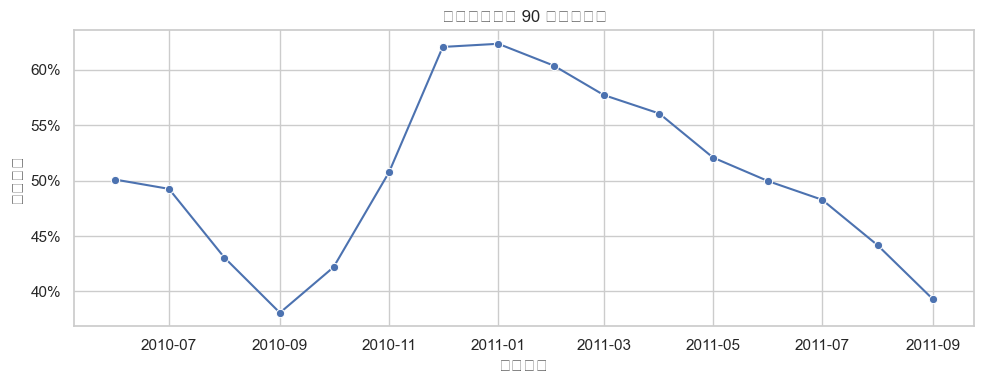

**结果解释：**共生成 **48,079** 个客户—月份样本，覆盖 **16** 个快照。整体 90 天不活跃率为 **50.9%**。不活跃率随月份变化，说明随机切分会混合不同时期的分布；因此下一步必须按时间验证。快照只纳入过去 180 天仍有交易的客户，模型回答的是‘近期客户中谁将停止购买’，而不是识别多年未出现的沉睡账户。

In [4]:
FEATURE_COLUMNS = [
    "recency_days", "customer_age_days",
    "orders_30d", "orders_90d", "orders_180d",
    "spend_30d", "spend_90d", "spend_180d",
    "units_30d", "units_90d", "units_180d",
    "avg_order_value_180d", "avg_lines_per_order_180d", "avg_units_per_order_180d",
    "distinct_skus_180d", "active_months_180d",
    "mean_purchase_interval_days", "std_purchase_interval_days",
    "spend_trend_30_vs_prior", "orders_trend_30_vs_prior",
    "cancelled_invoices_180d", "cancelled_value_180d", "is_uk"
]

first_purchase = successful.groupby("customer_id")["invoice_date"].min()

def window_aggregates(lines, snapshot, days, suffix):
    start = snapshot - pd.Timedelta(days=days)
    w = lines.loc[(lines.invoice_date >= start) & (lines.invoice_date < snapshot)].copy()
    if w.empty:
        return pd.DataFrame()
    invoice_level = w.groupby(["customer_id", "invoice"], as_index=False).agg(
        order_date=("invoice_date", "min"),
        order_value=("revenue", "sum"),
        order_units=("quantity", "sum"),
        order_lines=("stock_code", "size")
    )
    customer = invoice_level.groupby("customer_id").agg(
        **{
            f"orders_{suffix}": ("invoice", "nunique"),
            f"spend_{suffix}": ("order_value", "sum"),
            f"units_{suffix}": ("order_units", "sum")
        }
    )
    return customer

def build_snapshot(snapshot):
    lookback_start = snapshot - pd.Timedelta(days=180)
    hist = successful.loc[
        (successful.invoice_date >= lookback_start) & (successful.invoice_date < snapshot)
    ].copy()
    eligible = pd.Index(hist.customer_id.unique(), name="customer_id")
    if len(eligible) == 0:
        return pd.DataFrame()

    base = pd.DataFrame(index=eligible)
    last_purchase = hist.groupby("customer_id")["invoice_date"].max()
    base["recency_days"] = (snapshot - last_purchase).dt.total_seconds().div(86400)
    base["customer_age_days"] = (snapshot - first_purchase.reindex(eligible)).dt.total_seconds().div(86400)

    for days, suffix in [(30, "30d"), (90, "90d"), (180, "180d")]:
        base = base.join(window_aggregates(successful, snapshot, days, suffix), how="left")

    order_level = hist.groupby(["customer_id", "invoice"], as_index=False).agg(
        order_date=("invoice_date", "min"), order_value=("revenue", "sum"),
        order_units=("quantity", "sum"), order_lines=("stock_code", "size")
    )
    detail = order_level.groupby("customer_id").agg(
        avg_order_value_180d=("order_value", "mean"),
        avg_lines_per_order_180d=("order_lines", "mean"),
        avg_units_per_order_180d=("order_units", "mean")
    )
    base = base.join(detail, how="left")
    base["distinct_skus_180d"] = hist.groupby("customer_id")["stock_code"].nunique()
    base["active_months_180d"] = hist.assign(month=hist.invoice_date.dt.to_period("M")).groupby("customer_id")["month"].nunique()

    def interval_stats(group):
        dates = pd.Series(group.order_date.drop_duplicates().sort_values())
        gaps = dates.diff().dt.total_seconds().div(86400).dropna()
        return pd.Series({
            "mean_purchase_interval_days": gaps.mean(),
            "std_purchase_interval_days": gaps.std()
        })
    intervals = order_level.groupby("customer_id", group_keys=False).apply(interval_stats)
    base = base.join(intervals, how="left")

    prior_start = snapshot - pd.Timedelta(days=90)
    recent_start = snapshot - pd.Timedelta(days=30)
    recent = successful.loc[(successful.invoice_date >= recent_start) & (successful.invoice_date < snapshot)]
    prior = successful.loc[(successful.invoice_date >= prior_start) & (successful.invoice_date < recent_start)]
    recent_spend = recent.groupby("customer_id")["revenue"].sum().reindex(eligible, fill_value=0)
    prior_spend_monthly = prior.groupby("customer_id")["revenue"].sum().reindex(eligible, fill_value=0) / 2
    recent_orders = recent.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0)
    prior_orders_monthly = prior.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0) / 2
    base["spend_trend_30_vs_prior"] = (recent_spend + 1) / (prior_spend_monthly + 1)
    base["orders_trend_30_vs_prior"] = (recent_orders + 0.5) / (prior_orders_monthly + 0.5)

    r = returns.loc[(returns.invoice_date >= lookback_start) & (returns.invoice_date < snapshot)]
    base["cancelled_invoices_180d"] = r.groupby("customer_id")["invoice"].nunique().reindex(eligible, fill_value=0)
    base["cancelled_value_180d"] = r.groupby("customer_id")["return_value_abs"].sum().reindex(eligible, fill_value=0)
    main_country = hist.groupby("customer_id")["country"].agg(lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown")
    base["is_uk"] = main_country.eq("United Kingdom").astype(int)

    future_end = snapshot + pd.Timedelta(days=90)
    future_buyers = set(successful.loc[
        (successful.invoice_date >= snapshot) & (successful.invoice_date < future_end), "customer_id"
    ])
    base["inactive_90d"] = (~base.index.isin(future_buyers)).astype(int)
    base["snapshot_date"] = snapshot
    return base.reset_index()

snapshot_dates = pd.date_range("2010-06-01", "2011-09-01", freq="MS")
model_data = pd.concat([build_snapshot(date) for date in snapshot_dates], ignore_index=True)
model_data[FEATURE_COLUMNS] = model_data[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)

snapshot_summary = model_data.groupby("snapshot_date").agg(
    customers=("customer_id", "size"),
    inactive_customers=("inactive_90d", "sum"),
    inactivity_rate=("inactive_90d", "mean")
).reset_index()
display(snapshot_summary.style.format({"customers": "{:,.0f}", "inactive_customers": "{:,.0f}", "inactivity_rate": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=snapshot_summary, x="snapshot_date", y="inactivity_rate", marker="o", ax=ax)
ax.set(title="各月客户未来 90 天不活跃率", xlabel="快照月份", ylabel="不活跃率")
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

display(Markdown(
    f"**结果解释：**共生成 **{len(model_data):,}** 个客户—月份样本，覆盖 **{len(snapshot_dates)}** 个快照。"
    f"整体 90 天不活跃率为 **{model_data.inactive_90d.mean():.1%}**。"
    "不活跃率随月份变化，说明随机切分会混合不同时期的分布；因此下一步必须按时间验证。"
    "快照只纳入过去 180 天仍有交易的客户，模型回答的是‘近期客户中谁将停止购买’，而不是识别多年未出现的沉睡账户。"
))


## 5. 特征质量与业务含义

In [5]:
feature_dictionary = pd.DataFrame([
    ("recency_days", "最近一次购买距快照日的天数"),
    ("customer_age_days", "首次购买距快照日的天数"),
    ("orders/spend/units_30d/90d/180d", "不同窗口的频次、金额和件数"),
    ("avg_order_value_180d", "近 180 天平均订单金额"),
    ("distinct_skus_180d", "近 180 天购买商品丰富度"),
    ("purchase_interval", "订单间隔均值与波动"),
    ("spend/orders_trend", "近 30 天相对前 60 天月均水平的变化"),
    ("cancelled_*", "取消/退货发票数量与绝对金额"),
    ("is_uk", "客户主要国家是否为英国")
], columns=["特征组", "业务含义"])
missing = model_data[FEATURE_COLUMNS].isna().mean().sort_values(ascending=False).head(8).rename("缺失率").to_frame()
display(feature_dictionary)
display(missing.style.format("{:.1%}"))

display(Markdown(
    "**结果解释：**缺失主要来自‘购买间隔’：观察窗内只有一笔订单的客户没有可计算的间隔。"
    "这不是数据错误，建模管道会只用训练期中位数填补，避免用验证期或测试期信息。"
    "客户编号仅用于建立时间历史，未进入特征；模型不能靠记住客户 ID 得分。"
))


,特征组,业务含义
0,recency_days,最近一次购买距快照日的天数
1,customer_age_days,首次购买距快照日的天数
2,orders/spend/units_30d/90d/180d,不同窗口的频次、金额和件数
3,avg_order_value_180d,近 180 天平均订单金额
4,distinct_skus_180d,近 180 天购买商品丰富度
5,purchase_interval,订单间隔均值与波动
6,spend/orders_trend,近 30 天相对前 60 天月均水平的变化
7,cancelled_*,取消/退货发票数量与绝对金额
8,is_uk,客户主要国家是否为英国


,缺失率
std_purchase_interval_days,66.8%
orders_30d,66.6%
spend_30d,66.6%
units_30d,66.6%
mean_purchase_interval_days,45.4%
orders_90d,30.4%
spend_90d,30.4%
units_90d,30.4%


**结果解释：**缺失主要来自‘购买间隔’：观察窗内只有一笔订单的客户没有可计算的间隔。这不是数据错误，建模管道会只用训练期中位数填补，避免用验证期或测试期信息。客户编号仅用于建立时间历史，未进入特征；模型不能靠记住客户 ID 得分。

## 6. 带 90 天隔离期的滚动验证

如果用 2011-07-01 的客户状态做验证，训练快照的 90 天标签必须在 2011-07-01 之前已经完整观察到。因此训练数据最多只能用到 2011-04-01。这个 90 天隔离期比普通时间切分更严格，可防止标签窗口重叠造成的乐观结果。


In [6]:
validation_dates = pd.to_datetime(["2011-03-01", "2011-05-01", "2011-07-01"])
test_date = pd.Timestamp("2011-09-01")

split_rows = []
for i, val_date in enumerate(validation_dates, 1):
    train_cutoff = val_date - pd.Timedelta(days=90)
    train_mask = model_data.snapshot_date <= train_cutoff
    val_mask = model_data.snapshot_date == val_date
    split_rows.append({
        "阶段": f"滚动验证 {i}", "训练快照截止": model_data.loc[train_mask, "snapshot_date"].max(),
        "验证快照": val_date, "训练样本": train_mask.sum(), "验证样本": val_mask.sum()
    })

final_train_cutoff = test_date - pd.Timedelta(days=90)
final_train_mask = model_data.snapshot_date <= final_train_cutoff
final_test_mask = model_data.snapshot_date == test_date
split_rows.append({
    "阶段": "最终留出测试", "训练快照截止": model_data.loc[final_train_mask, "snapshot_date"].max(),
    "验证快照": test_date, "训练样本": final_train_mask.sum(), "验证样本": final_test_mask.sum()
})
split_table = pd.DataFrame(split_rows)
display(split_table)
display(Markdown(
    "**结果解释：**模型选择只使用前三个滚动验证月；最后的 2011-09 快照完全留到模型选定后再评估。"
    "每个训练截止日与验证日之间至少相隔 90 天，所以训练标签在预测时点之前已经成熟。"
))


,阶段,训练快照截止,验证快照,训练样本,验证样本
0,滚动验证 1,2010-12-01,2011-03-01,20677,3349
1,滚动验证 2,2011-01-01,2011-05-01,24092,3049
2,滚动验证 3,2011-04-01,2011-07-01,34104,2724
3,最终留出测试,2011-06-01,2011-09-01,39812,2772


**结果解释：**模型选择只使用前三个滚动验证月；最后的 2011-09 快照完全留到模型选定后再评估。每个训练截止日与验证日之间至少相隔 90 天，所以训练标签在预测时点之前已经成熟。

## 7. 比较四类模型

In [7]:
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, brier_score_loss
)
from xgboost import XGBClassifier

def make_models(y):
    neg, pos = (y == 0).sum(), (y == 1).sum()
    ratio = neg / max(pos, 1)
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1500, class_weight="balanced", random_state=42))
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=180, min_samples_leaf=10, max_features="sqrt",
                class_weight="balanced_subsample", n_jobs=1, random_state=42
            ))
        ]),
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                max_iter=180, learning_rate=0.05, max_leaf_nodes=15,
                l2_regularization=1.0, random_state=42
            ))
        ]),
        "XGBoost": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=240, max_depth=4, learning_rate=0.04,
                subsample=0.85, colsample_bytree=0.85, min_child_weight=8,
                reg_lambda=2.0, objective="binary:logistic", eval_metric="logloss",
                scale_pos_weight=ratio, n_jobs=4, random_state=42
            ))
        ])
    }

def score_probabilities(y_true, prob):
    pred = (prob >= 0.5).astype(int)
    return {
        "PR-AUC": average_precision_score(y_true, prob),
        "ROC-AUC": roc_auc_score(y_true, prob),
        "Precision@0.5": precision_score(y_true, pred, zero_division=0),
        "Recall@0.5": recall_score(y_true, pred, zero_division=0),
        "F1@0.5": f1_score(y_true, pred, zero_division=0),
        "Brier": brier_score_loss(y_true, prob)
    }

cv_rows = []
for fold, val_date in enumerate(validation_dates, 1):
    cutoff = val_date - pd.Timedelta(days=90)
    train = model_data.loc[model_data.snapshot_date <= cutoff]
    valid = model_data.loc[model_data.snapshot_date == val_date]
    X_train, y_train = train[FEATURE_COLUMNS], train.inactive_90d
    X_valid, y_valid = valid[FEATURE_COLUMNS], valid.inactive_90d
    for name, model in make_models(y_train).items():
        fit_kwargs = {}
        if name == "HistGradientBoosting":
            class_weight = np.where(y_train.to_numpy() == 1, (y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
            fit_kwargs["model__sample_weight"] = class_weight
        model.fit(X_train, y_train, **fit_kwargs)
        prob = model.predict_proba(X_valid)[:, 1]
        cv_rows.append({"fold": fold, "validation_month": val_date, "model": name, **score_probabilities(y_valid, prob)})

cv_results = pd.DataFrame(cv_rows)
cv_summary = cv_results.groupby("model").agg(
    mean_pr_auc=("PR-AUC", "mean"), std_pr_auc=("PR-AUC", "std"),
    mean_roc_auc=("ROC-AUC", "mean"), mean_f1=("F1@0.5", "mean"),
    mean_brier=("Brier", "mean")
).sort_values("mean_pr_auc", ascending=False)
display(cv_summary.style.format("{:.3f}"))

best_model_name = cv_summary.index[0]
cv_results.to_csv(OUTPUT_DIR / "rolling_time_validation.csv", index=False)
cv_summary.to_csv(OUTPUT_DIR / "model_comparison_summary.csv")

display(Markdown(
    f"**结果解释：**按主指标平均 PR-AUC，滚动验证表现最好的模型是 **{best_model_name}**，"
    f"平均 PR-AUC 为 **{cv_summary.iloc[0].mean_pr_auc:.3f}**。"
    "PR-AUC 比准确率更适合评估需要优先排序的风险任务；ROC-AUC 衡量整体排序，Brier 越低表示概率误差越小。"
    "这里不根据最后测试月选模型，因此测试结果仍是一次真正的样本外检验。"
))


  File "C:\Users\J\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,mean_pr_auc,std_pr_auc,mean_roc_auc,mean_f1,mean_brier
model,,,,,
Logistic Regression,0.744,0.030,0.758,0.716,0.200
HistGradientBoosting,0.742,0.035,0.756,0.724,0.200
XGBoost,0.741,0.031,0.753,0.724,0.200
Random Forest,0.731,0.036,0.751,0.708,0.202


**结果解释：**按主指标平均 PR-AUC，滚动验证表现最好的模型是 **Logistic Regression**，平均 PR-AUC 为 **0.744**。PR-AUC 比准确率更适合评估需要优先排序的风险任务；ROC-AUC 衡量整体排序，Brier 越低表示概率误差越小。这里不根据最后测试月选模型，因此测试结果仍是一次真正的样本外检验。

## 8. 最终留出测试：2011-09 客户快照

In [8]:
train = model_data.loc[final_train_mask]
test = model_data.loc[final_test_mask].copy()
X_train, y_train = train[FEATURE_COLUMNS], train.inactive_90d
X_test, y_test = test[FEATURE_COLUMNS], test.inactive_90d

final_model = make_models(y_train)[best_model_name]
fit_kwargs = {}
if best_model_name == "HistGradientBoosting":
    class_weight = np.where(y_train.to_numpy() == 1, (y_train == 0).sum() / max((y_train == 1).sum(), 1), 1.0)
    fit_kwargs["model__sample_weight"] = class_weight
final_model.fit(X_train, y_train, **fit_kwargs)
test_prob = final_model.predict_proba(X_test)[:, 1]

final_metrics = score_probabilities(y_test, test_prob)
baseline_pr_auc = y_test.mean()
metrics_table = pd.DataFrame({
    "指标": list(final_metrics.keys()) + ["无模型排序的 PR-AUC 基线"],
    "结果": list(final_metrics.values()) + [baseline_pr_auc]
})
display(metrics_table.style.format({"结果": "{:.3f}"}))

pd.DataFrame([{"model": best_model_name, **final_metrics, "positive_rate": y_test.mean()}]).to_csv(
    OUTPUT_DIR / "final_holdout_metrics.csv", index=False
)

display(Markdown(
    f"**结果解释：**最终测试月包含 **{len(test):,}** 个近期客户，实际不活跃率为 **{y_test.mean():.1%}**。"
    f"选定模型的 PR-AUC 为 **{final_metrics['PR-AUC']:.3f}**，高于不做排序时的基线 **{baseline_pr_auc:.3f}**；"
    f"ROC-AUC 为 **{final_metrics['ROC-AUC']:.3f}**。"
    "这说明模型能够进行风险排序，但测试月只有一个时间截面，不能把该分数解释为所有未来月份都能保持不变。"
))


,指标,结果
0,PR-AUC,0.628
1,ROC-AUC,0.740
2,Precision@0.5,0.548
3,Recall@0.5,0.720
4,F1@0.5,0.622
5,Brier,0.203
6,无模型排序的 PR-AUC 基线,0.393


**结果解释：**最终测试月包含 **2,772** 个近期客户，实际不活跃率为 **39.3%**。选定模型的 PR-AUC 为 **0.628**，高于不做排序时的基线 **0.393**；ROC-AUC 为 **0.740**。这说明模型能够进行风险排序，但测试月只有一个时间截面，不能把该分数解释为所有未来月份都能保持不变。

## 9. 把概率变成运营名单：Top 10% 与风险十分位

In [9]:
scored = test[["customer_id", "snapshot_date", "inactive_90d"]].copy()
scored["risk_score"] = test_prob
scored = scored.sort_values("risk_score", ascending=False).reset_index(drop=True)
k = max(1, int(np.ceil(len(scored) * 0.10)))
top = scored.head(k)
precision_at_10 = top.inactive_90d.mean()
recall_at_10 = top.inactive_90d.sum() / scored.inactive_90d.sum()
lift_at_10 = precision_at_10 / scored.inactive_90d.mean()

scored["risk_decile"] = pd.qcut(scored.risk_score.rank(method="first"), 10, labels=False) + 1
deciles = scored.groupby("risk_decile").agg(
    customers=("customer_id", "size"),
    average_score=("risk_score", "mean"),
    actual_inactivity_rate=("inactive_90d", "mean")
).reset_index().sort_values("risk_decile", ascending=False)
display(pd.DataFrame({
    "运营指标": ["Top 10% 客户数", "Top 10% 精确率", "Top 10% 召回率", "Top 10% Lift"],
    "结果": [k, precision_at_10, recall_at_10, lift_at_10]
}).style.format({"结果": lambda x: f"{x:,.3f}"}))
display(deciles.style.format({"customers": "{:,.0f}", "average_score": "{:.3f}", "actual_inactivity_rate": "{:.1%}"}))

deciles.to_csv(OUTPUT_DIR / "final_test_risk_deciles.csv", index=False)
# 不导出公开客户 ID 名单，只保留聚合结果；真实业务中该名单应进入受控 CRM 环境。

display(Markdown(
    f"**结果解释：**如果运营容量只允许触达最高风险的 10%（**{k:,}** 人），"
    f"其中实际未来 90 天未购买的比例为 **{precision_at_10:.1%}**，可覆盖全部不活跃客户的 **{recall_at_10:.1%}**，"
    f"相对不做模型筛选的 Lift 为 **{lift_at_10:.2f} 倍**。"
    "这展示的是名单浓缩能力，不是召回活动带来的增量效果；是否值得发券仍要结合成本、利润和随机对照实验。"
))


,运营指标,结果
0,Top 10% 客户数,278.000
1,Top 10% 精确率,0.748
2,Top 10% 召回率,0.191
3,Top 10% Lift,1.905


,risk_decile,customers,average_score,actual_inactivity_rate
9,10,278,0.733,74.8%
8,9,277,0.680,52.7%
7,8,277,0.637,54.2%
6,7,277,0.587,50.2%
5,6,277,0.540,43.0%
4,5,277,0.478,46.9%
3,4,277,0.402,29.2%
2,3,277,0.299,24.2%
1,2,277,0.174,14.4%
0,1,278,0.056,3.2%


**结果解释：**如果运营容量只允许触达最高风险的 10%（**278** 人），其中实际未来 90 天未购买的比例为 **74.8%**，可覆盖全部不活跃客户的 **19.1%**，相对不做模型筛选的 Lift 为 **1.90 倍**。这展示的是名单浓缩能力，不是召回活动带来的增量效果；是否值得发券仍要结合成本、利润和随机对照实验。

## 10. 概率校准与主要预测信号

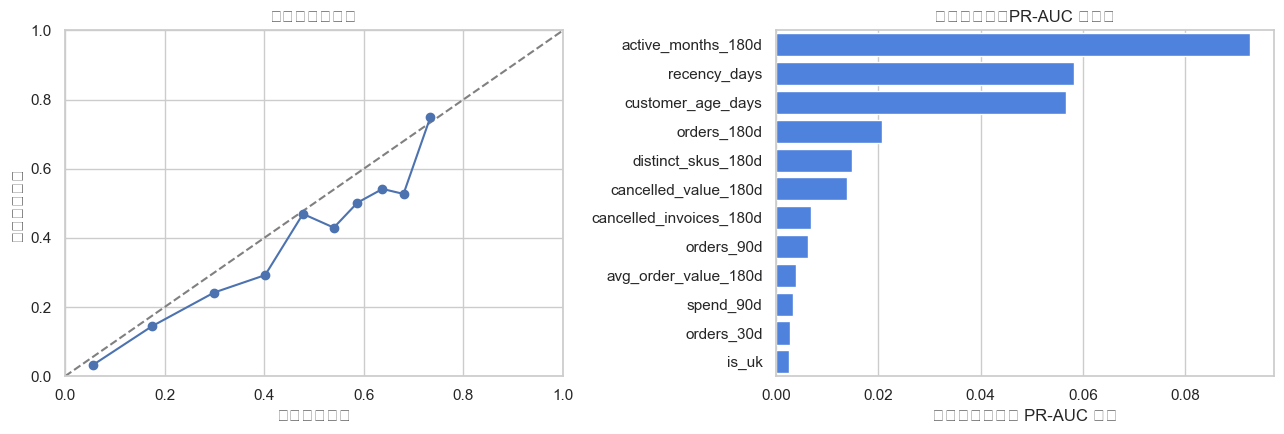

,calibration_bin,customers,mean_predicted_risk,actual_inactivity_rate
0,1,278,5.6%,3.2%
1,2,277,17.4%,14.4%
2,3,277,29.9%,24.2%
3,4,277,40.2%,29.2%
4,5,277,47.8%,46.9%
5,6,277,54.0%,43.0%
6,7,277,58.7%,50.2%
7,8,277,63.7%,54.2%
8,9,277,68.0%,52.7%
9,10,278,73.3%,74.8%


,feature,pr_auc_drop,std
15,active_months_180d,0.0927,0.0039
0,recency_days,0.0582,0.0040
1,customer_age_days,0.0566,0.0024
4,orders_180d,0.0208,0.0076
14,distinct_skus_180d,0.0148,0.0028
21,cancelled_value_180d,0.0139,0.0028
20,cancelled_invoices_180d,0.0068,0.0053
3,orders_90d,0.0063,0.0025
11,avg_order_value_180d,0.0039,0.0014
6,spend_90d,0.0034,0.0006


**结果解释：**测试集 Brier 分数为 **0.203**；校准图比较‘模型预测概率’与‘实际发生率’，两者越接近对角线，概率越适合直接用于资源和预算估算。置换重要性排名靠前的信号为 **active_months_180d, recency_days, customer_age_days, orders_180d, distinct_skus_180d**。重要性表示这些变量对样本外预测有帮助，不代表改变它们会因果地阻止客户不活跃。

In [10]:
from sklearn.inspection import permutation_importance

scored["calibration_bin"] = pd.qcut(scored.risk_score.rank(method="first"), 10, labels=False) + 1
calibration = scored.groupby("calibration_bin").agg(
    customers=("customer_id", "size"),
    mean_predicted_risk=("risk_score", "mean"),
    actual_inactivity_rate=("inactive_90d", "mean")
).reset_index()

perm_sample = X_test.sample(min(2500, len(X_test)), random_state=42)
perm_y = y_test.loc[perm_sample.index]
perm = permutation_importance(
    final_model, perm_sample, perm_y, scoring="average_precision",
    n_repeats=4, random_state=42, n_jobs=1
)
importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "pr_auc_drop": perm.importances_mean,
    "std": perm.importances_std
}).sort_values("pr_auc_drop", ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].plot(calibration.mean_predicted_risk, calibration.actual_inactivity_rate, marker="o")
axes[0].set(title="十分位概率校准", xlabel="平均预测风险", ylabel="实际不活跃率", xlim=(0, 1), ylim=(0, 1))
sns.barplot(data=importance, y="feature", x="pr_auc_drop", ax=axes[1], color="#367BF5")
axes[1].set(title="置换重要性（PR-AUC 降幅）", xlabel="打乱该特征后的 PR-AUC 降幅", ylabel="")
plt.tight_layout()
plt.show()
display(calibration.style.format({"customers": "{:,.0f}", "mean_predicted_risk": "{:.1%}", "actual_inactivity_rate": "{:.1%}"}))
display(importance.style.format({"pr_auc_drop": "{:.4f}", "std": "{:.4f}"}))

calibration.to_csv(OUTPUT_DIR / "final_test_calibration.csv", index=False)
importance.to_csv(OUTPUT_DIR / "permutation_importance.csv", index=False)

top_features = ", ".join(importance.head(5).feature.tolist())
display(Markdown(
    f"**结果解释：**测试集 Brier 分数为 **{final_metrics['Brier']:.3f}**；校准图比较‘模型预测概率’与‘实际发生率’，"
    "两者越接近对角线，概率越适合直接用于资源和预算估算。"
    f"置换重要性排名靠前的信号为 **{top_features}**。"
    "重要性表示这些变量对样本外预测有帮助，不代表改变它们会因果地阻止客户不活跃。"
))


## 11. 业务结论与下一步

### 可以支持的决策

1. 每月对过去 180 天内仍有交易的客户进行风险评分；
2. 在固定触达容量下，优先将最高风险层送入 CRM 候选名单；
3. 按风险十分位监控实际不活跃率、概率校准与模型漂移；
4. 对高风险名单继续设置随机对照组，衡量邮件、优惠券或客服触达的真实增量。

### 当前项目不能证明的内容

- 90 天未购买不等于永久流失；
- 高风险因素是预测关系，不是因果关系；
- 数据没有营销成本、毛利与触达结果，不能直接计算召回 ROI；
- 数据来自单一英国零售商，迁移到天猫、京东、拼多多或 Amazon 前必须重新定义窗口、标签和阈值。

### 生产化扩展

- 用 SQL 每月生成相同口径的客户快照；
- 只在标签成熟后更新训练集，并保留至少 90 天隔离期；
- 记录数据版本、特征版本、模型版本与阈值；
- 监控 PR-AUC、Top-K Lift、校准、特征漂移和召回实验增量。

这个项目直接对应简历中的 **classification models for behavioral data analysis with systematic cross-validation**，也通过可复现特征管道和模型评估对应 **reproducible Python/SQL pipelines**。若要强化简历中“150,000+ 样本”的聚类表述，应该另做客户分群项目，不应把本项目的重复月度快照冒充 150,000 个独立客户。
